In [1]:
import pandas as pd
import janitor
from IPython.display import display
from utilities import calculate_summary_statistics, pandas_to_tex
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="white", context="notebook", font_scale=1.3)
from statsmodels.nonparametric.smoothers_lowess import lowess

from utilities import save_mpl_fig
from constants import AGE_ORDER, var_labels, bl_measures, bl_measures_cumulative, bl_al1, bl_al10, palette7, linestyles7

Checking that all paths exist:
{'web_mobile': True, 'web_desktop': True, 'web': False, 'yg_profile': True, 'blacklight': True, 'who': True}


## Prep data

In [2]:
df = pd.read_csv("../data/combined_yg_bl_who_derived_hist_tracking.csv").assign(
    agegroup_lab=lambda df_: pd.Categorical(
        df_["agegroup_lab"], categories=AGE_ORDER, ordered=True
    )
)
display(df.head())
df.info(verbose=True)

,Unnamed: 0,caseid,tt_visits,tt_domains,bl_ddg_join_ads,bl_third_party_cookies,bl_canvas_fingerprinting,bl_session_recording,bl_key_logging,bl_fb_pixel,...,who_adult_advertising_al5,who_adult_advertising_al10,n_orgs,top_org_share,top_org_visits,top_org_share_duration,gini_exposure,captured_visits,who_visits,who_coverage
0,0,47541,17194,553,161861.0,172095.0,1451.0,1173.0,3909.0,2715.0,...,False,False,495,0.608759,10467.0,0.714545,0.854956,0.795975,12229,0.711236
1,1,56565,11479,334,97694.0,103287.0,222.0,185.0,1625.0,585.0,...,False,False,371,0.596132,6843.0,0.671141,0.815088,0.766095,7932,0.691001
2,2,203271,6540,152,11317.0,22787.0,137.0,786.0,10.0,24.0,...,False,False,151,0.363150,2375.0,0.338349,0.832871,0.731498,4447,0.679969
3,3,216457,1770,49,19793.0,5050.0,22.0,10.0,2.0,10.0,...,False,False,110,0.766102,1356.0,0.874906,0.676575,0.809040,1300,0.734463
4,4,257495,10012,284,73761.0,77189.0,1516.0,445.0,2036.0,1221.0,...,False,False,288,0.601578,6023.0,0.659628,0.815267,0.712046,7368,0.735917


<class 'pandas.DataFrame'>
RangeIndex: 1134 entries, 0 to 1133
Data columns (total 151 columns):
 #    Column                                    Dtype   
---   ------                                    -----   
 0    Unnamed: 0                                int64   
 1    caseid                                    int64   
 2    tt_visits                                 int64   
 3    tt_domains                                int64   
 4    bl_ddg_join_ads                           float64 
 5    bl_third_party_cookies                    float64 
 6    bl_canvas_fingerprinting                  float64 
 7    bl_session_recording                      float64 
 8    bl_key_logging                            float64 
 9    bl_fb_pixel                               float64 
 10   bl_google_analytics                       float64 
 11   who_adult_advertising                     float64 
 12   who_advertising                           float64 
 13   who_audio_video_player                    

In [3]:
# 2 caseid has no tracking data at all
df.query("bl_third_party_cookies!=bl_third_party_cookies")

,Unnamed: 0,caseid,tt_visits,tt_domains,bl_ddg_join_ads,bl_third_party_cookies,bl_canvas_fingerprinting,bl_session_recording,bl_key_logging,bl_fb_pixel,...,who_adult_advertising_al5,who_adult_advertising_al10,n_orgs,top_org_share,top_org_visits,top_org_share_duration,gini_exposure,captured_visits,who_visits,who_coverage


In [4]:
# Two panelists (2 and 13 visits) spent them entirely on domains Blacklight
# never scanned, so every bl_* measure is a genuine zero rather than missing --
# the lower bound the paper is explicit about. They also have no WhoTracksMe
# coverage, so dropping rows with any who_* NaN silently removed exactly the two
# zero-exposure users from Tables 2 and 3 and nudged every incidence figure up.
# Blacklight summaries therefore keep all 1,134; WhoTracksMe summaries take the
# WTM-covered subset, since a WTM rate is undefined without WTM visits.
BL_COLS = bl_measures_cumulative + bl_measures
df = df.dropna(subset=BL_COLS)
df_wtm = df[df["who_coverage"] > 0]
print(f"Blacklight panel: {len(df):,}   WhoTracksMe-covered: {len(df_wtm):,}")

Blacklight panel: 1,134   WhoTracksMe-covered: 1,132


In [5]:
df["tt_visits"].describe()

count     1134.000000
mean      5499.853616
std       8247.085805
min          2.000000
25%        755.250000
50%       2542.000000
75%       7147.000000
max      86659.000000
Name: tt_visits, dtype: float64

In [6]:
df["tt_domains"].describe()

count    1134.000000
mean      164.373898
std       153.312611
min         1.000000
25%        53.250000
50%       122.500000
75%       220.000000
max      1009.000000
Name: tt_domains, dtype: float64

## BL

### Exposure rate

In [7]:
# exposure rate
df_bl_summ_exposure_rate = (
    df.select_columns(bl_measures)
    .describe(percentiles=[0.25, 0.5, 0.75])
    # =====================================================
    # Tidy table and Fromat numbers
    .T.reset_index(names="var")
    #     .assign(count=lambda df_: df_["count"].apply(lambda x: f"{int(x):,}"))
    .remove_columns("count")
    .map(lambda x: f"{x:,.2f}" if isinstance(x, (float, int)) else x)
    .replace("_rate", "", regex=True)
    # =====================================================
    .assign(var=lambda df_: df_["var"].replace(var_labels))
)
pandas_to_tex(
    df_bl_summ_exposure_rate, "../tables/individual_blacklight_exposure_rate_summary"
)
df_bl_summ_exposure_rate

,var,mean,std,min,25%,50%,75%,max
0,Ad Trackers,4.98,3.64,0.00,2.66,3.99,6.28,31.41
1,Third-Party Cookies,6.12,5.05,0.00,3.26,4.83,7.36,53.42
2,Facebook Pixel,0.08,0.09,0.00,0.03,0.06,0.11,1.00
3,Google Analytics (Remarketing),0.01,0.04,0.00,0.00,0.00,0.01,0.99
4,Session Recording,0.03,0.05,0.00,0.01,0.02,0.04,0.59
5,Keylogging,0.04,0.07,0.00,0.00,0.01,0.04,0.58
6,Canvas Fingerprinting,0.06,0.09,0.00,0.01,0.04,0.07,1.00


In [8]:
!cat ../tables/individual_blacklight_exposure_rate_summary.tex

Ad Trackers & 4.98 & 3.64 & 0.00 & 2.66 & 3.99 & 6.28 & 31.41 \\
Third-Party Cookies & 6.12 & 5.05 & 0.00 & 3.26 & 4.83 & 7.36 & 53.42 \\
Facebook Pixel & 0.08 & 0.09 & 0.00 & 0.03 & 0.06 & 0.11 & 1.00 \\
Google Analytics (Remarketing) & 0.01 & 0.04 & 0.00 & 0.00 & 0.00 & 0.01 & 0.99 \\
Session Recording & 0.03 & 0.05 & 0.00 & 0.01 & 0.02 & 0.04 & 0.59 \\
Keylogging & 0.04 & 0.07 & 0.00 & 0.00 & 0.01 & 0.04 & 0.58 \\
Canvas Fingerprinting & 0.06 & 0.09 & 0.00 & 0.01 & 0.04 & 0.07 & 1.00 \\

### Cumulative

In [9]:
# cumulative exposure
df_bl_summ_cum_exposure = (
    df.select_columns(bl_measures_cumulative)
    .describe(percentiles=[0.25, 0.5, 0.75])
    # =====================================================
    # Tidy table and Fromat numbers
    .T.reset_index(names="var")
    .remove_columns("count")
    .map(lambda x: f"{x:,.0f}" if isinstance(x, (float, int)) else x)
    # =====================================================
    # Get at least one
    .merge(
        (
            df.select_columns(bl_al1)
            .mean()
            .multiply(100)
            .round(1)
            .astype(str)
            .add("\%")
            .reset_index(name="atleast1")
            .rename_column("index", "var")
            .replace("_al1", "", regex=True)
        ),
        how="left",
        on="var",
        validate="1:1",
    )
    # =====================================================
    # Get at least ten
    .merge(
        (
            df.select_columns(bl_al10)
            .mean()
            .multiply(100)
            .round(1)
            .astype(str)
            .add("\%")
            .reset_index(name="atleast10")
            .rename_column("index", "var")
            .replace("_al10", "", regex=True)
        ),
        how="left",
        on="var",
        validate="1:1",
    )
    .assign(var=lambda df_: df_["var"].replace(var_labels))
)
pandas_to_tex(
    df_bl_summ_cum_exposure,
    "../tables/individual_blacklight_cumulative_exposure_summary",
)
df_bl_summ_cum_exposure

,var,mean,std,min,25%,50%,75%,max,atleast1,atleast10
0,Ad Trackers,"27,407","48,279",0,"2,620","9,738","29,240","517,968",99.6\%,99.1\%
1,Third-Party Cookies,"32,325","55,184",0,"3,133","11,757","35,647","700,142",99.4\%,99.1\%
2,Facebook Pixel,383,657,0,40,147,463,"5,808",94.7\%,87.3\%
3,Google Analytics (Remarketing),35,104,0,0,8,29,"1,619",72.4\%,46.5\%
4,Session Recording,155,353,0,10,54,165,"5,788",89.7\%,76.0\%
5,Keylogging,309,935,0,4,26,148,"10,315",84.9\%,65.9\%
6,Canvas Fingerprinting,320,697,0,18,84,288,"7,643",91.7\%,81.0\%


## WTM

### Exposure rate

In [10]:
wtm_measures = [
    #     "who_tracking_requests_per_page_load_rate",
    "who_trackers_per_page_load_rate",
]

In [11]:
# exposure rate
df_who_summ_exposure_rate = (
    df_wtm.select_columns(wtm_measures)
    .describe(percentiles=[0.25, 0.5, 0.75])
    # =====================================================
    # Tidy table and Fromat numbers
    .T.reset_index(names="var")
    #     .assign(count=lambda df_: df_["count"].apply(lambda x: f"{int(x):,}"))
    .remove_columns("count")
    .round(1)
    .map(lambda x: f"{x:,.1f}" if isinstance(x, (float, int)) else x)
    .replace("_rate", "", regex=True)
    # =====================================================
    .assign(var=lambda df_: df_["var"].replace(var_labels))
)
# tables/individual_who_*_summary.tex are written by
# 16_who_coverage.py, which divides by WhoTracksMe-covered visits
# rather than all visits; this cell is display-only.
df_who_summ_exposure_rate

,var,mean,std,min,25%,50%,75%,max
0,Trackers/Page Load,5.3,1.7,1.6,4.2,5.0,5.9,21.0


### Cumulative

In [12]:
wtm_measures_cum = [
    #     "who_tracking_requests_per_page_load",
    "who_trackers_per_page_load",
]

In [13]:
# cumulative exposure
df_who_summ_cum_exposure = (
    df_wtm.select_columns(wtm_measures_cum)
    .describe(percentiles=[0.25, 0.5, 0.75])
    # =====================================================
    # Tidy table and Fromat numbers
    .T.reset_index(names="var")
    .remove_columns("count")
    .map(lambda x: f"{x:,.0f}" if isinstance(x, (float, int)) else x)
    # =====================================================
    # Get at least one
    .merge(
        (
            df_wtm.select_columns(
                [
                    "who_tracking_requests_per_page_load_al1",
                    "who_trackers_per_page_load_al1",
                ]
            )
            .mean()
            .multiply(100)
            .round(1)
            .astype(str)
            .add("\%")
            .reset_index(name="atleast1")
            .rename_column("index", "var")
            .replace("_al1", "", regex=True)
        ),
        how="left",
        on="var",
        validate="1:1",
    )
    # =====================================================
    # Get at least ten
    .merge(
        (
            df_wtm.select_columns(
                [
                    "who_tracking_requests_per_page_load_al10",
                    "who_trackers_per_page_load_al10",
                ]
            )
            .mean()
            .multiply(100)
            .round(1)
            .astype(str)
            .add("\%")
            .reset_index(name="atleast10")
            .rename_column("index", "var")
            .replace("_al10", "", regex=True)
        ),
        how="left",
        on="var",
        validate="1:1",
    )
    .assign(var=lambda df_: df_["var"].replace(var_labels))
)
# tables/individual_who_*_summary.tex are written by
# 16_who_coverage.py, which divides by WhoTracksMe-covered visits
# rather than all visits; this cell is display-only.
df_who_summ_cum_exposure

,var,mean,std,min,25%,50%,75%,max,atleast1,atleast10
0,Trackers/Page Load,"19,590","29,611",4,"2,168","8,812","25,001","282,508",100.0\%,99.6\%


## Summ by demo

In [14]:
percentiles = [5, 10, 25, 50, 75, 90, 95]

In [15]:
demo_group = ["gender_lab", "race_lab", "educ_lab", "agegroup_lab"]

In [16]:
results = []
for measure in ["tt_visits", "tt_domains"]:
    for demo in demo_group:
        summary_df = calculate_summary_statistics(
            df,
            groupby_column=demo,
            value_column=measure,
            percentiles=percentiles,
        ).assign(tracker_measure=measure)

        if demo == "agegroup_lab":
            summary_df = summary_df.sort_values(by=demo)

        display(summary_df)
        results.append(summary_df)

,gender_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,Female,595 (52.5\%),5091.6,7177.6,2,71.4,202.2,730.5,2306.0,6496.0,14326.8,19119.8,48510,tt_visits
1,Male,539 (47.5\%),5950.5,9271.8,2,61.5,163.8,767.5,2665.0,7625.0,14353.8,21273.3,86659,tt_visits


,race_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,White,720 (63.5\%),5779.7,8172.5,2,78.0,227.1,839.0,2773.0,7528.0,15435.6,20742.9,79210,tt_visits
1,Hispanic,168 (14.8\%),4490.5,8565.4,2,40.0,154.0,497.0,1592.0,5030.2,11893.2,14469.2,86659,tt_visits
2,Black,144 (12.7\%),4867.1,8163.6,3,64.5,141.5,702.2,1917.0,4973.2,12547.7,19378.8,46415,tt_visits
3,Other,56 (4.9\%),5130.5,6654.8,11,41.2,104.5,598.2,1978.0,7793.0,12734.0,16323.8,29292,tt_visits
4,Asian,46 (4.1\%),7236.9,9875.8,6,18.5,223.0,1134.2,3996.5,10771.5,16080.5,18525.5,54986,tt_visits


,educ_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,HS or Below,411 (36.2\%),4691.2,7441.4,2,50.0,135.0,525.5,1702.0,5517.5,12880.0,19017.5,79210,tt_visits
1,Some college,326 (28.7\%),5140.9,7423.7,2,99.5,235.5,860.0,2361.5,6691.2,12498.5,18998.2,53193,tt_visits
2,College,255 (22.5\%),6755.0,9919.7,4,142.5,306.0,965.5,3130.0,9130.5,17455.8,22187.5,86659,tt_visits
3,Postgrad,142 (12.5\%),6410.6,8679.3,5,39.2,134.5,1080.0,3674.0,7634.2,15118.4,21316.8,53725,tt_visits


,agegroup_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
4,<25,106 (9.3\%),3700.3,6071.9,12,49.8,137.0,517.0,1482.5,3970.0,9094.0,14992.2,41350,tt_visits
3,25-34,200 (17.6\%),4893.3,10285.6,2,24.6,166.0,722.8,1493.0,4521.2,11742.2,17754.4,86659,tt_visits
0,35-49,291 (25.7\%),4801.4,7209.1,2,58.0,122.0,550.0,1917.0,5607.5,13687.0,19261.0,53725,tt_visits
1,50-64,280 (24.7\%),5885.6,7958.8,16,92.0,249.7,865.5,2649.5,8070.2,15127.2,20354.1,53193,tt_visits
2,65+,257 (22.7\%),7084.7,8419.2,5,152.6,346.8,1349.0,4144.0,9509.0,17802.2,21884.6,48510,tt_visits


,gender_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,Female,595 (52.5\%),166.8,153.6,1,11.0,24.0,57.5,125.0,219.5,348.4,474.9,1009,tt_domains
1,Male,539 (47.5\%),161.6,153.1,1,10.0,19.8,48.0,113.0,221.0,375.2,467.5,956,tt_domains


,race_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,White,720 (63.5\%),171.9,156.9,1,13.9,24.9,55.0,125.0,234.2,372.1,504.1,928,tt_domains
1,Hispanic,168 (14.8\%),143.5,125.1,1,6.0,15.7,48.0,106.5,210.2,288.7,403.4,797,tt_domains
2,Black,144 (12.7\%),155.3,176.9,2,8.2,18.3,47.2,108.5,183.2,329.4,471.0,1009,tt_domains
3,Other,56 (4.9\%),151.5,127.6,4,7.8,14.5,48.2,136.5,216.5,320.5,363.2,671,tt_domains
4,Asian,46 (4.1\%),167.5,133.7,2,3.8,17.0,64.5,146.5,225.8,395.5,422.2,505,tt_domains


,educ_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,HS or Below,411 (36.2\%),145.2,141.1,1,8.0,17.0,43.0,105.0,195.0,329.0,417.5,891,tt_domains
1,Some college,326 (28.7\%),162.8,148.2,1,12.2,21.0,60.2,120.5,222.0,345.0,442.5,956,tt_domains
2,College,255 (22.5\%),187.7,171.7,1,17.7,28.0,61.0,138.0,271.5,388.8,518.2,1009,tt_domains
3,Postgrad,142 (12.5\%),181.6,157.8,1,4.1,15.4,79.8,151.0,219.0,422.2,481.8,879,tt_domains


,agegroup_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
4,<25,106 (9.3\%),118.9,135.4,3,6.5,13.5,37.2,79.0,149.0,229.0,394.0,956,tt_domains
3,25-34,200 (17.6\%),133.0,122.7,1,4.0,18.9,45.0,95.5,181.0,284.7,380.5,797,tt_domains
0,35-49,291 (25.7\%),150.4,140.0,1,8.5,17.0,46.5,116.0,207.5,323.0,401.5,1009,tt_domains
1,50-64,280 (24.7\%),179.4,155.2,4,19.8,29.0,68.8,135.0,235.5,379.8,500.2,930,tt_domains
2,65+,257 (22.7\%),206.9,180.2,1,15.0,28.0,75.0,159.0,284.0,437.0,552.2,928,tt_domains


In [17]:
results = []
for measure in bl_measures:
    for demo in demo_group:
        summary_df = calculate_summary_statistics(
            df,
            groupby_column=demo,
            value_column=measure,
            percentiles=percentiles,
        ).assign(tracker_measure=measure)

        if demo == "agegroup_lab":
            summary_df = summary_df.sort_values(by=demo)

        display(summary_df)
        results.append(summary_df)

,gender_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,Female,595 (52.5\%),4.9,3.5,0.0,1.3,1.8,2.7,4.0,6.2,9.4,11.6,30.7,bl_ddg_join_ads_rate
1,Male,539 (47.5\%),5.0,3.8,0.0,1.3,1.7,2.5,3.9,6.3,9.3,12.9,31.4,bl_ddg_join_ads_rate


,race_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,White,720 (63.5\%),5.2,3.6,0.0,1.4,1.8,2.8,4.2,6.5,9.8,12.6,25.9,bl_ddg_join_ads_rate
1,Hispanic,168 (14.8\%),4.7,3.9,0.0,1.4,1.7,2.6,3.6,6.1,9.0,12.3,30.7,bl_ddg_join_ads_rate
2,Black,144 (12.7\%),4.8,3.8,0.0,1.2,1.5,2.4,4.0,6.2,8.6,11.6,31.4,bl_ddg_join_ads_rate
3,Other,56 (4.9\%),4.8,3.5,1.1,1.4,1.8,2.5,3.8,6.1,9.4,12.0,18.1,bl_ddg_join_ads_rate
4,Asian,46 (4.1\%),3.5,1.9,0.0,0.6,1.5,2.5,3.5,4.3,5.2,7.1,9.2,bl_ddg_join_ads_rate


,educ_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,HS or Below,411 (36.2\%),4.8,3.8,0.0,1.2,1.6,2.4,3.7,6.2,9.3,11.6,30.7,bl_ddg_join_ads_rate
1,Some college,326 (28.7\%),4.8,3.6,0.0,1.5,1.8,2.6,3.9,5.8,9.1,12.5,31.4,bl_ddg_join_ads_rate
2,College,255 (22.5\%),5.2,3.7,0.0,1.3,1.9,2.9,4.2,6.4,10.0,12.8,25.9,bl_ddg_join_ads_rate
3,Postgrad,142 (12.5\%),5.3,3.0,0.0,1.8,2.3,3.1,4.7,6.8,8.5,10.9,16.0,bl_ddg_join_ads_rate


,agegroup_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
4,<25,106 (9.3\%),3.1,1.8,0.9,1.3,1.6,2.1,2.7,3.8,4.4,6.2,13.6,bl_ddg_join_ads_rate
3,25-34,200 (17.6\%),3.8,2.7,0.0,0.5,1.3,2.3,3.2,4.5,6.7,8.1,18.4,bl_ddg_join_ads_rate
0,35-49,291 (25.7\%),5.1,3.8,0.0,1.4,1.8,2.7,4.2,6.3,9.0,12.3,30.7,bl_ddg_join_ads_rate
1,50-64,280 (24.7\%),5.4,3.9,0.2,1.5,2.0,2.8,4.3,6.8,10.2,12.7,31.4,bl_ddg_join_ads_rate
2,65+,257 (22.7\%),6.1,3.8,0.0,1.6,2.2,3.4,5.1,7.8,11.0,13.4,22.2,bl_ddg_join_ads_rate


,gender_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,Female,595 (52.5\%),6.1,4.9,0.0,1.6,2.2,3.4,4.9,7.3,11.2,14.2,53.4,bl_third_party_cookies_rate
1,Male,539 (47.5\%),6.1,5.2,0.0,1.6,2.0,3.2,4.8,7.4,11.0,14.7,43.9,bl_third_party_cookies_rate


...

,agegroup_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
4,<25,106 (9.3\%),0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.5,bl_key_logging_rate
3,25-34,200 (17.6\%),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.3,bl_key_logging_rate
0,35-49,291 (25.7\%),0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.2,0.6,bl_key_logging_rate
1,50-64,280 (24.7\%),0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.2,0.4,bl_key_logging_rate
2,65+,257 (22.7\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.2,0.2,0.4,bl_key_logging_rate


,gender_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,Female,595 (52.5\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.2,0.3,0.8,bl_canvas_fingerprinting_rate
1,Male,539 (47.5\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.2,1.0,bl_canvas_fingerprinting_rate


,race_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,White,720 (63.5\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.2,1.0,bl_canvas_fingerprinting_rate
1,Hispanic,168 (14.8\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.2,0.5,bl_canvas_fingerprinting_rate
2,Black,144 (12.7\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.2,0.6,bl_canvas_fingerprinting_rate
3,Other,56 (4.9\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.2,0.2,0.4,bl_canvas_fingerprinting_rate
4,Asian,46 (4.1\%),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.1,0.2,bl_canvas_fingerprinting_rate


,educ_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,HS or Below,411 (36.2\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.2,1.0,bl_canvas_fingerprinting_rate
1,Some college,326 (28.7\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.2,0.7,bl_canvas_fingerprinting_rate
2,College,255 (22.5\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.2,0.6,bl_canvas_fingerprinting_rate
3,Postgrad,142 (12.5\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.2,0.2,0.8,bl_canvas_fingerprinting_rate


,agegroup_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
4,<25,106 (9.3\%),0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.1,0.5,bl_canvas_fingerprinting_rate
3,25-34,200 (17.6\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.2,0.4,bl_canvas_fingerprinting_rate
0,35-49,291 (25.7\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.2,1.0,bl_canvas_fingerprinting_rate
1,50-64,280 (24.7\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.2,0.6,bl_canvas_fingerprinting_rate
2,65+,257 (22.7\%),0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.2,0.3,0.8,bl_canvas_fingerprinting_rate


In [18]:
results = []
for measure in wtm_measures:
    for demo in demo_group:
        summary_df = calculate_summary_statistics(
            df_wtm,
            groupby_column=demo,
            value_column=measure,
            percentiles=percentiles,
        ).assign(tracker_measure=measure)

        if demo == "agegroup_lab":
            summary_df = summary_df.sort_values(by=demo)

        display(summary_df)
        results.append(summary_df)

,gender_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,Female,595 (52.6\%),5.2,1.7,1.6,3.3,3.6,4.2,5.0,6.0,7.1,8.2,21.0,who_trackers_per_page_load_rate
1,Male,537 (47.4\%),5.3,1.8,1.8,3.3,3.7,4.2,5.0,5.9,7.3,9.1,13.4,who_trackers_per_page_load_rate


,race_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,White,719 (63.5\%),5.3,1.8,1.6,3.3,3.7,4.2,5.0,6.0,7.3,8.6,21.0,who_trackers_per_page_load_rate
1,Hispanic,168 (14.8\%),5.2,1.6,2.1,3.5,3.7,4.1,4.9,5.7,7.1,8.0,11.9,who_trackers_per_page_load_rate
2,Black,144 (12.7\%),5.0,1.5,1.6,2.8,3.5,4.1,4.9,5.7,6.7,7.2,12.9,who_trackers_per_page_load_rate
3,Other,56 (4.9\%),5.5,1.7,2.6,3.4,3.8,4.3,5.3,6.1,7.5,9.0,11.4,who_trackers_per_page_load_rate
4,Asian,45 (4.0\%),5.2,1.9,2.9,3.6,3.7,4.2,4.6,5.7,7.2,8.6,12.5,who_trackers_per_page_load_rate


,educ_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
0,HS or Below,409 (36.1\%),5.2,1.9,1.6,3.2,3.6,4.1,4.9,5.8,6.9,8.2,21.0,who_trackers_per_page_load_rate
1,Some college,326 (28.8\%),5.2,1.7,1.6,3.2,3.6,4.1,4.9,5.9,7.1,8.2,13.1,who_trackers_per_page_load_rate
2,College,255 (22.5\%),5.5,1.7,2.1,3.5,3.8,4.3,5.1,6.2,7.8,9.4,12.5,who_trackers_per_page_load_rate
3,Postgrad,142 (12.5\%),5.2,1.3,2.6,3.6,3.8,4.4,4.9,5.8,7.0,8.0,9.5,who_trackers_per_page_load_rate


,agegroup_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
4,<25,106 (9.4\%),4.7,1.1,2.3,3.4,3.5,4.0,4.6,5.4,6.0,6.4,9.1,who_trackers_per_page_load_rate
3,25-34,198 (17.5\%),4.9,1.6,1.6,3.2,3.6,4.0,4.7,5.4,6.7,7.9,13.4,who_trackers_per_page_load_rate
0,35-49,291 (25.7\%),5.3,1.8,2.6,3.5,3.8,4.2,5.0,5.9,7.4,8.2,21.0,who_trackers_per_page_load_rate
1,50-64,280 (24.7\%),5.4,1.6,1.7,3.1,3.7,4.4,5.0,6.1,7.4,8.8,11.8,who_trackers_per_page_load_rate
2,65+,257 (22.7\%),5.6,1.9,1.6,3.4,3.7,4.4,5.2,6.3,7.9,9.6,13.1,who_trackers_per_page_load_rate


In [19]:
summary_df

,agegroup_lab,count,mean,std,min,5,10,25,50,75,90,95,max,tracker_measure
4,<25,106 (9.4\%),4.7,1.1,2.3,3.4,3.5,4.0,4.6,5.4,6.0,6.4,9.1,who_trackers_per_page_load_rate
3,25-34,198 (17.5\%),4.9,1.6,1.6,3.2,3.6,4.0,4.7,5.4,6.7,7.9,13.4,who_trackers_per_page_load_rate
0,35-49,291 (25.7\%),5.3,1.8,2.6,3.5,3.8,4.2,5.0,5.9,7.4,8.2,21.0,who_trackers_per_page_load_rate
1,50-64,280 (24.7\%),5.4,1.6,1.7,3.1,3.7,4.4,5.0,6.1,7.4,8.8,11.8,who_trackers_per_page_load_rate
2,65+,257 (22.7\%),5.6,1.9,1.6,3.4,3.7,4.4,5.2,6.3,7.9,9.6,13.1,who_trackers_per_page_load_rate


In [20]:
print(summary_df.to_latex())

\begin{tabular}{lllrrrrrrrrrrrl}
\toprule
 & agegroup_lab & count & mean & std & min & 5 & 10 & 25 & 50 & 75 & 90 & 95 & max & tracker_measure \\
\midrule
4 & <25 & 106 (9.4\%) & 4.700000 & 1.100000 & 2.300000 & 3.400000 & 3.500000 & 4.000000 & 4.600000 & 5.400000 & 6.000000 & 6.400000 & 9.100000 & who_trackers_per_page_load_rate \\
3 & 25-34 & 198 (17.5\%) & 4.900000 & 1.600000 & 1.600000 & 3.200000 & 3.600000 & 4.000000 & 4.700000 & 5.400000 & 6.700000 & 7.900000 & 13.400000 & who_trackers_per_page_load_rate \\
0 & 35-49 & 291 (25.7\%) & 5.300000 & 1.800000 & 2.600000 & 3.500000 & 3.800000 & 4.200000 & 5.000000 & 5.900000 & 7.400000 & 8.200000 & 21.000000 & who_trackers_per_page_load_rate \\
1 & 50-64 & 280 (24.7\%) & 5.400000 & 1.600000 & 1.700000 & 3.100000 & 3.700000 & 4.400000 & 5.000000 & 6.100000 & 7.400000 & 8.800000 & 11.800000 & who_trackers_per_page_load_rate \\
2 & 65+ & 257 (22.7\%) & 5.600000 & 1.900000 & 1.600000 & 3.400000 & 3.700000 & 4.400000 & 5.200000 & 6.300000 & 

## Exposure rate against age

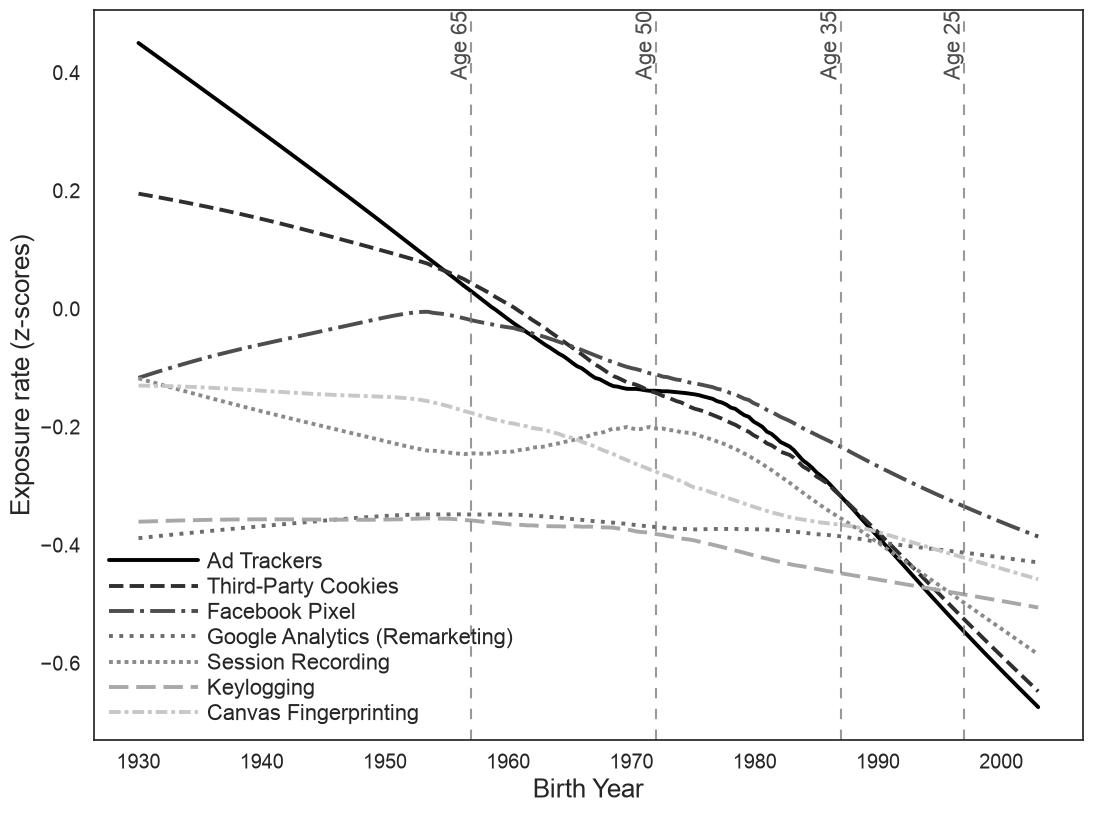

In [21]:
# plot
_scale = .7
_aspect_ratio = (16,12)
figsize = tuple(k * _scale for k in _aspect_ratio)
fig, ax = plt.subplots(figsize=figsize)

# ===============================================================
birthyr_grid = np.linspace(df["birthyr"].min(), df["birthyr"].max(), 200)
ref_ages = [25, 35, 50, 65]
ref_birthyrs = [2022 - age for age in ref_ages]
    
# ===============================================================
for ix, var in enumerate(bl_measures):
    df_plot = df.copy()

    # Winsorize
    low, high = df_plot[var].quantile([0.0, 0.95])
    df_plot[var] = df_plot[var].clip(lower=low, upper=high)

    # z-standardise
    df_plot[var] = (df_plot[var] - df_plot[var].mean()) / df_plot[var].std()

    # LOWESS
    smoothed = lowess(
        endog=df_plot[var],
        exog=df_plot["birthyr"],
        frac=0.5,
        it=3,
        delta=0.0,
        xvals=birthyr_grid,
    )

    ax.plot(
        birthyr_grid,
        smoothed,
        label=var_labels[var],
        linewidth=2.8,
        linestyle=linestyles7[ix],
        color=palette7[ix],
    )

# ===============================================================
# Reference vertical lines for ages
for birthyr, age in zip(ref_birthyrs, ref_ages):
    ax.axvline(x=birthyr, linestyle= (0, (5, 5)), color=".5", alpha=0.8)
    ax.text(
        x=birthyr,
        y=ax.get_ylim()[1] - 0.002,
        s=f"Age {age}",
        rotation=90,
        verticalalignment="top",
        horizontalalignment="right",
        fontsize=16,
        color=".3",
    )

# ===============================================================
# Legend formatting
ax.legend(
    title="",
#     title_fontsize=15,
    fontsize=16,
    loc="lower left",
    frameon=False,
    borderpad=0.2,
    handlelength=4,
    handletextpad=0.4,
    labelspacing=0.2,
)

# ===============================================================
LABEL_SIZE = 19
ax.set_xlabel("Birth Year", fontsize=LABEL_SIZE)
ax.set_ylabel("Exposure rate (z-scores)", fontsize=LABEL_SIZE)

plt.grid(axis="both", visible=False)

plt.tight_layout()
save_mpl_fig("../figures/lowess_age_bl")

## Correlation

In [22]:
x = [
    #  'tt_visits',
    #  'tt_domains',
    "bl_ddg_join_ads_rate",
    "bl_third_party_cookies_rate",
    "bl_fb_pixel_rate",
    "bl_google_analytics_rate",
    "bl_session_recording_rate",
    "bl_key_logging_rate",
    "bl_canvas_fingerprinting_rate",
    "who_trackers_per_page_load_rate",
    "who_tracking_requests_per_page_load_rate",
    #  'who_trackers_requests_all_requests_rate',
    #  'who_data_saved_rate',
    "who_advertising_rate",
    "who_audio_video_player_rate",
    "who_customer_interaction_rate",
    "who_hosting_rate",
    "who_consent_management_rate",
    "who_site_analytics_rate",
    "who_misc_rate",
    "who_utilities_rate",
    "who_social_media_rate",
    "who_adult_advertising_rate",
]
x

['bl_ddg_join_ads_rate',
 'bl_third_party_cookies_rate',
 'bl_fb_pixel_rate',
 'bl_google_analytics_rate',
 'bl_session_recording_rate',
 'bl_key_logging_rate',
 'bl_canvas_fingerprinting_rate',
 'who_trackers_per_page_load_rate',
 'who_tracking_requests_per_page_load_rate',
 'who_advertising_rate',
 'who_audio_video_player_rate',
 'who_customer_interaction_rate',
 'who_hosting_rate',
 'who_consent_management_rate',
 'who_site_analytics_rate',
 'who_misc_rate',
 'who_utilities_rate',
 'who_social_media_rate',
 'who_adult_advertising_rate']

In [23]:
updated_var_labels = {
    k: (
        f"{v} (BL)"
        if k.startswith("bl_")
        else f"{v} (WTM)"
        if k.startswith("who_")
        else v
    )
    for k, v in var_labels.items()
}

df_corr_ = (
    df.select_columns(x).corr().rename(index=updated_var_labels, columns=var_labels)
)
df_corr_

,Ad Trackers,Third-Party Cookies,Facebook Pixel,Google Analytics (Remarketing),Session Recording,Keylogging,Canvas Fingerprinting,Trackers/Page Load,Tracking Requests/Page Load,Advertising,Audio/Video Player,Customer Interaction,Hosting Services,Consent Management,Site Analytics,Miscellaneous,Utilities,Social Media,Adult Advertising
Ad Trackers (BL),1.000000,0.878858,0.370910,0.140661,0.210037,0.509985,0.420473,0.348124,0.243586,0.479013,0.230307,0.384833,0.163567,0.202761,0.398684,0.145426,0.142888,0.278402,-0.046157
Third-Party Cookies (BL),0.878858,1.000000,0.254895,0.180933,0.201716,0.369230,0.465274,0.272493,0.148996,0.346841,0.141471,0.373922,0.162505,0.177788,0.300029,0.256477,0.097386,0.171574,-0.049742
Facebook Pixel (BL),0.370910,0.254895,1.000000,0.390265,0.355750,0.028160,0.275208,0.137494,0.036881,0.118640,0.003689,0.141969,0.002466,0.210428,0.276972,-0.175051,0.285880,-0.000607,-0.037008
Google Analytics (Remarketing) (BL),0.140661,0.180933,0.390265,1.000000,0.147237,-0.022870,0.245098,0.001051,0.002816,-0.019586,-0.030074,0.026329,0.028668,0.015830,0.061898,-0.070115,0.072904,-0.056985,-0.008598
Session Recording (BL),0.210037,0.201716,0.355750,0.147237,1.000000,0.015897,0.169289,0.122614,0.000267,0.112945,-0.016971,0.110855,0.005961,0.104325,0.188004,-0.104790,0.222261,0.045502,-0.045207
Keylogging (BL),0.509985,0.369230,0.028160,-0.022870,0.015897,1.000000,-0.006338,0.115969,0.137343,0.385649,0.283264,0.215281,0.102788,-0.000665,0.182750,0.006890,-0.030183,0.373823,-0.070077
Canvas Fingerprinting (BL),0.420473,0.465274,0.275208,0.245098,0.169289,-0.006338,1.000000,0.064769,0.061525,0.008900,-0.143439,0.294129,0.090224,0.065781,0.130773,0.380673,0.212173,-0.089994,-0.049224
Trackers/Page Load (WTM),0.348124,0.272493,0.137494,0.001051,0.122614,0.115969,0.064769,1.000000,0.466472,0.785525,0.428912,0.490734,0.288737,0.587725,0.757833,-0.096221,0.448504,0.414062,-0.051230
Tracking Requests/Page Load (WTM),0.243586,0.148996,0.036881,0.002816,0.000267,0.137343,0.061525,0.466472,1.000000,0.578310,0.201687,0.407079,0.168956,0.359308,0.453645,0.206906,0.205236,0.229179,-0.037495
Advertising (WTM),0.479013,0.346841,0.118640,-0.019586,0.112945,0.385649,0.008900,0.785525,0.578310,1.000000,0.483037,0.557354,0.326217,0.543642,0.757318,0.017883,0.324075,0.500808,-0.106045


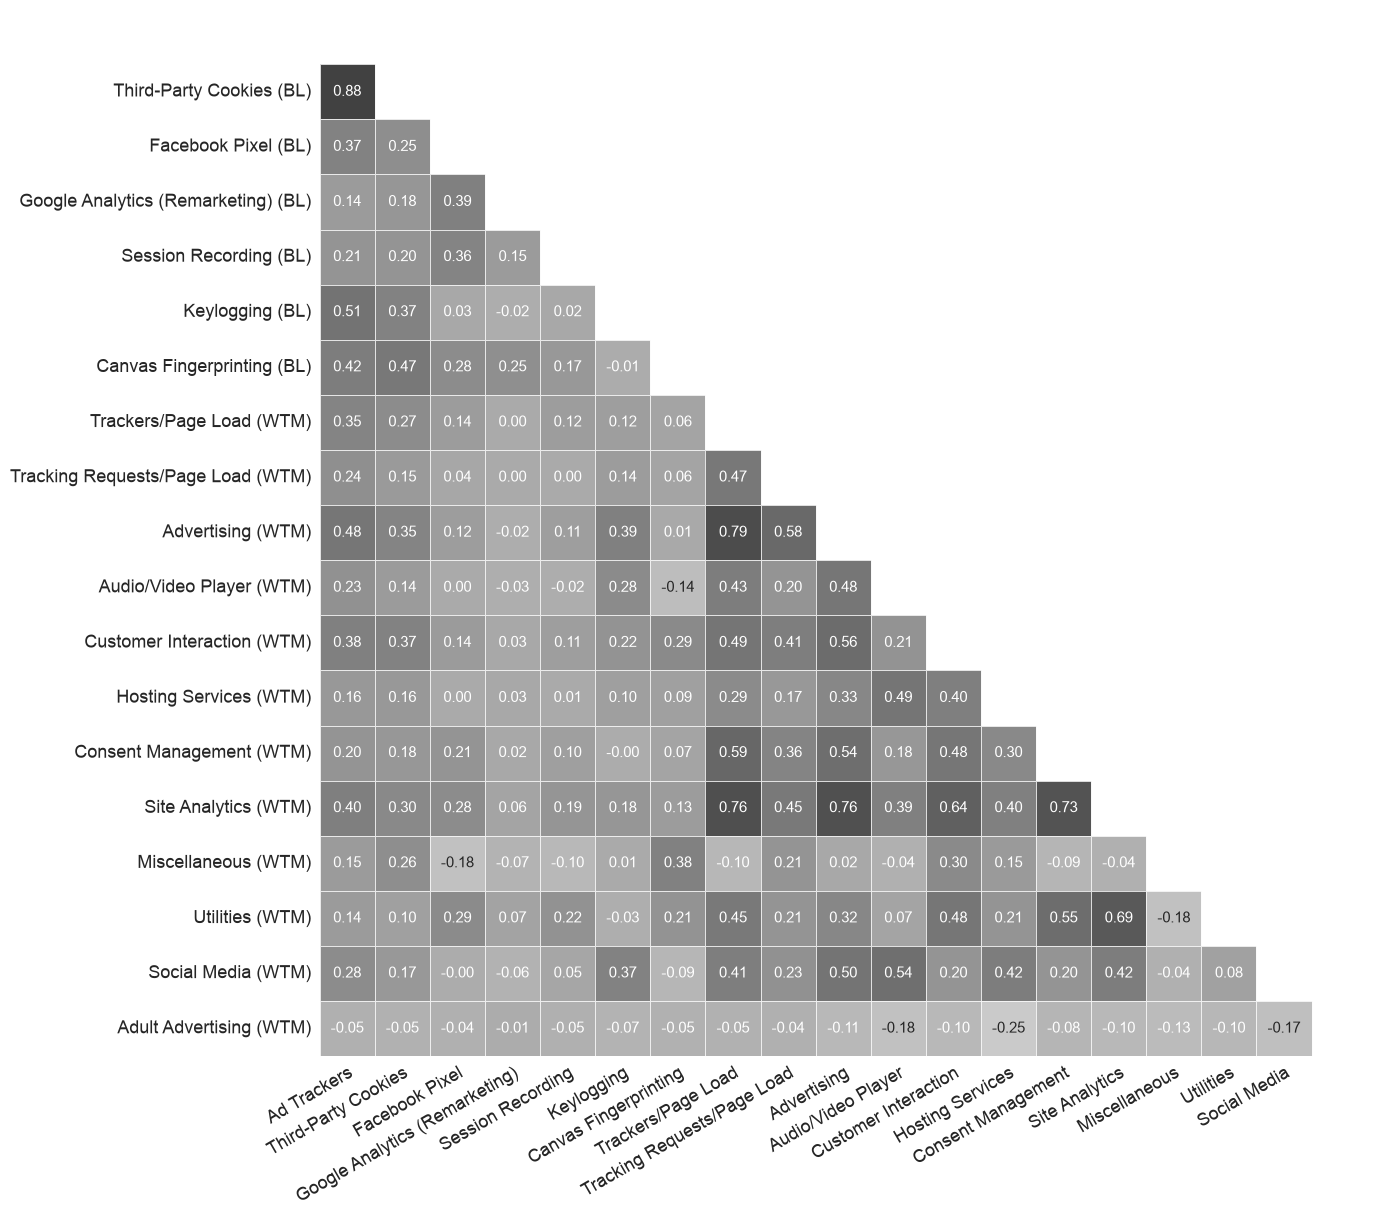

In [24]:
# plot correlations
_scale = 1
_aspect_ratio = (14, 14)
figsize = tuple(k * _scale for k in _aspect_ratio)
fig, ax = plt.subplots(figsize=figsize)

# Heatmap without colorbar for now
sns.heatmap(
    df_corr_,
    # remove upper tri
    mask=np.triu(np.ones_like(df_corr_, dtype=bool)),
    cmap="Greys",
    alpha=0.8,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 11},
    cbar=False,
    ax=ax,
)

# ===============================================================
# # Cbar
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# # Prep axis
# cax = inset_axes(
#     ax,
#     width="5%",
#     height="40%",
#     loc='upper right',
#     bbox_to_anchor=(
#         -0.15,  # x offset
#          -0.1,  # y offs
#          1,     # width scaling: leave it at 100% of parent box (not used here)
#          1      # height scaling: same as above
#     ),
#     # relative position
#     bbox_transform=ax.transAxes,
#     borderpad=0,
# )

# # Add colorbar
# norm = plt.Normalize(vmin=-1, vmax=1)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# cbar = fig.colorbar(sm, cax=cax, orientation="vertical")
# cbar.set_label("Correlation", fontsize=11)
# cbar.ax.tick_params(labelsize=9)

# ===============================================================
yticklabels = ax.get_yticklabels()
# remove first redundant label
yticklabels[0] = ""
ax.set_yticklabels(yticklabels)

xticklabels = [label.get_text() for label in ax.get_xticklabels()]
# remove last redundant label
xticklabels[-1] = ""
ax.set_xticklabels(xticklabels, rotation=30, ha="right", rotation_mode="anchor")

ax.tick_params(axis="both", labelsize=13, pad=0)

plt.tight_layout()
save_mpl_fig("../figures/bl_wtm_correlation")

### BL + WTM tarckers/page

In [25]:
x = [
    #  'tt_visits',
    #  'tt_domains',
    "bl_ddg_join_ads_rate",
    "bl_third_party_cookies_rate",
    "bl_fb_pixel_rate",
    "bl_google_analytics_rate",
    "bl_session_recording_rate",
    "bl_key_logging_rate",
    "bl_canvas_fingerprinting_rate",
    "who_trackers_per_page_load_rate",
]
x

['bl_ddg_join_ads_rate',
 'bl_third_party_cookies_rate',
 'bl_fb_pixel_rate',
 'bl_google_analytics_rate',
 'bl_session_recording_rate',
 'bl_key_logging_rate',
 'bl_canvas_fingerprinting_rate',
 'who_trackers_per_page_load_rate']

In [26]:
updated_var_labels = {
    k: (
        f"{v} (BL)"
        if k.startswith("bl_")
        else f"{v} (WTM)"
        if k.startswith("who_")
        else v
    )
    for k, v in var_labels.items()
}

df_corr_ = (
    df
    .reorder_columns(x)
    .select_columns(x).corr().rename(index=updated_var_labels, columns=var_labels)
)
df_corr_

,Ad Trackers,Third-Party Cookies,Facebook Pixel,Google Analytics (Remarketing),Session Recording,Keylogging,Canvas Fingerprinting,Trackers/Page Load
Ad Trackers (BL),1.000000,0.878858,0.370910,0.140661,0.210037,0.509985,0.420473,0.348124
Third-Party Cookies (BL),0.878858,1.000000,0.254895,0.180933,0.201716,0.369230,0.465274,0.272493
Facebook Pixel (BL),0.370910,0.254895,1.000000,0.390265,0.355750,0.028160,0.275208,0.137494
Google Analytics (Remarketing) (BL),0.140661,0.180933,0.390265,1.000000,0.147237,-0.022870,0.245098,0.001051
Session Recording (BL),0.210037,0.201716,0.355750,0.147237,1.000000,0.015897,0.169289,0.122614
Keylogging (BL),0.509985,0.369230,0.028160,-0.022870,0.015897,1.000000,-0.006338,0.115969
Canvas Fingerprinting (BL),0.420473,0.465274,0.275208,0.245098,0.169289,-0.006338,1.000000,0.064769
Trackers/Page Load (WTM),0.348124,0.272493,0.137494,0.001051,0.122614,0.115969,0.064769,1.000000


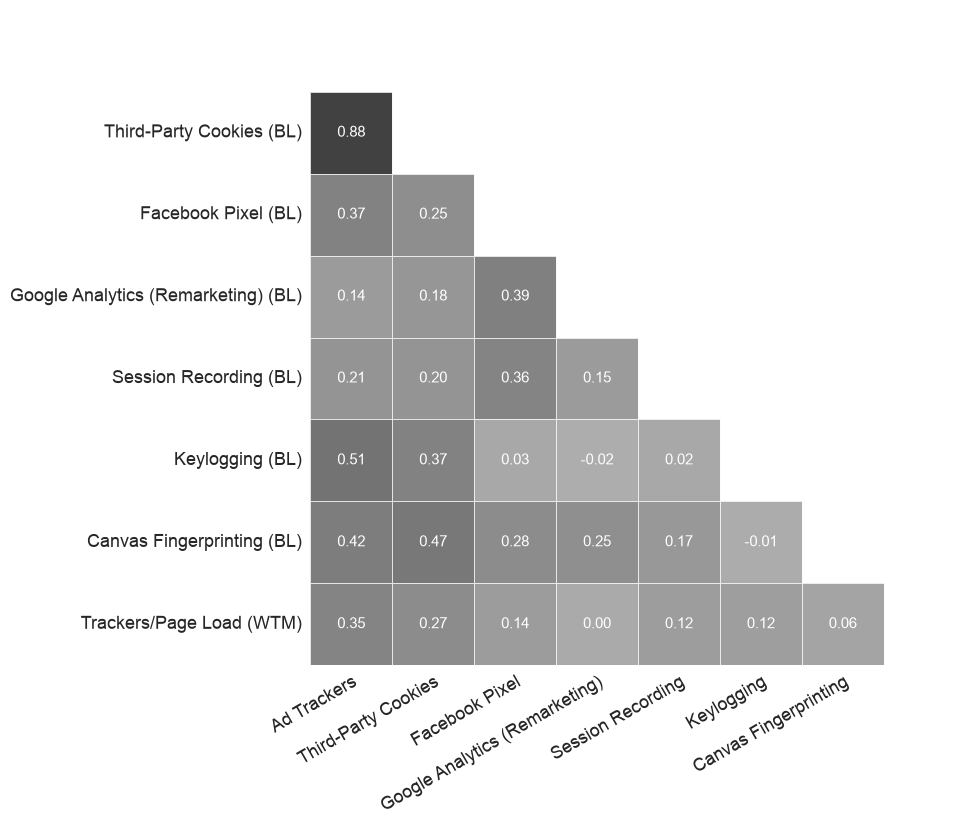

In [27]:
# plot correlations
_scale = 1
_aspect_ratio = (10, 10)
figsize = tuple(k * _scale for k in _aspect_ratio)
fig, ax = plt.subplots(figsize=figsize)

# Heatmap without colorbar for now
sns.heatmap(
    df_corr_,
    # remove upper tri
    mask=np.triu(np.ones_like(df_corr_, dtype=bool)),
    cmap="Greys",
    alpha=0.8,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 11},
    cbar=False,
    ax=ax,
)

# ===============================================================
yticklabels = ax.get_yticklabels()
# remove first redundant label
yticklabels[0] = ""
ax.set_yticklabels(yticklabels)

xticklabels = [label.get_text() for label in ax.get_xticklabels()]
# remove last redundant label
xticklabels[-1] = ""
ax.set_xticklabels(xticklabels, rotation=30, ha="right", rotation_mode="anchor")

ax.tick_params(axis="both", labelsize=13, pad=0)

plt.tight_layout()
save_mpl_fig("../figures/bl_wtm_correlation_truncated")

### BL + WTM tarckers/page -- cumulative

In [28]:
x = [
    "bl_ddg_join_ads",
    "bl_third_party_cookies",
    "bl_fb_pixel",
    "bl_google_analytics",
    "bl_session_recording",
    "bl_key_logging",
    "bl_canvas_fingerprinting",
    "who_trackers_per_page_load",
]
x

['bl_ddg_join_ads',
 'bl_third_party_cookies',
 'bl_fb_pixel',
 'bl_google_analytics',
 'bl_session_recording',
 'bl_key_logging',
 'bl_canvas_fingerprinting',
 'who_trackers_per_page_load']

In [29]:
updated_var_labels = {
    k: (
        f"{v} (BL)"
        if k.startswith("bl_")
        else f"{v} (WTM)"
        if k.startswith("who_")
        else v
    )
    for k, v in var_labels.items()
}

df_corr_ = (
    df
    .reorder_columns(x)
    .select_columns(x).corr().rename(index=updated_var_labels, columns=var_labels)
)
df_corr_

,Ad Trackers,Third-Party Cookies,Facebook Pixel,Google Analytics (Remarketing),Session Recording,Keylogging,Canvas Fingerprinting,Trackers/Page Load
Ad Trackers (BL),1.000000,0.957219,0.718085,0.320955,0.557317,0.717951,0.568111,0.825593
Third-Party Cookies (BL),0.957219,1.000000,0.704213,0.329835,0.602717,0.646719,0.625502,0.805067
Facebook Pixel (BL),0.718085,0.704213,1.000000,0.389857,0.612187,0.381906,0.645294,0.684817
Google Analytics (Remarketing) (BL),0.320955,0.329835,0.389857,1.000000,0.255496,0.202954,0.286493,0.349201
Session Recording (BL),0.557317,0.602717,0.612187,0.255496,1.000000,0.289561,0.434341,0.478441
Keylogging (BL),0.717951,0.646719,0.381906,0.202954,0.289561,1.000000,0.233634,0.561689
Canvas Fingerprinting (BL),0.568111,0.625502,0.645294,0.286493,0.434341,0.233634,1.000000,0.541759
Trackers/Page Load (WTM),0.825593,0.805067,0.684817,0.349201,0.478441,0.561689,0.541759,1.000000


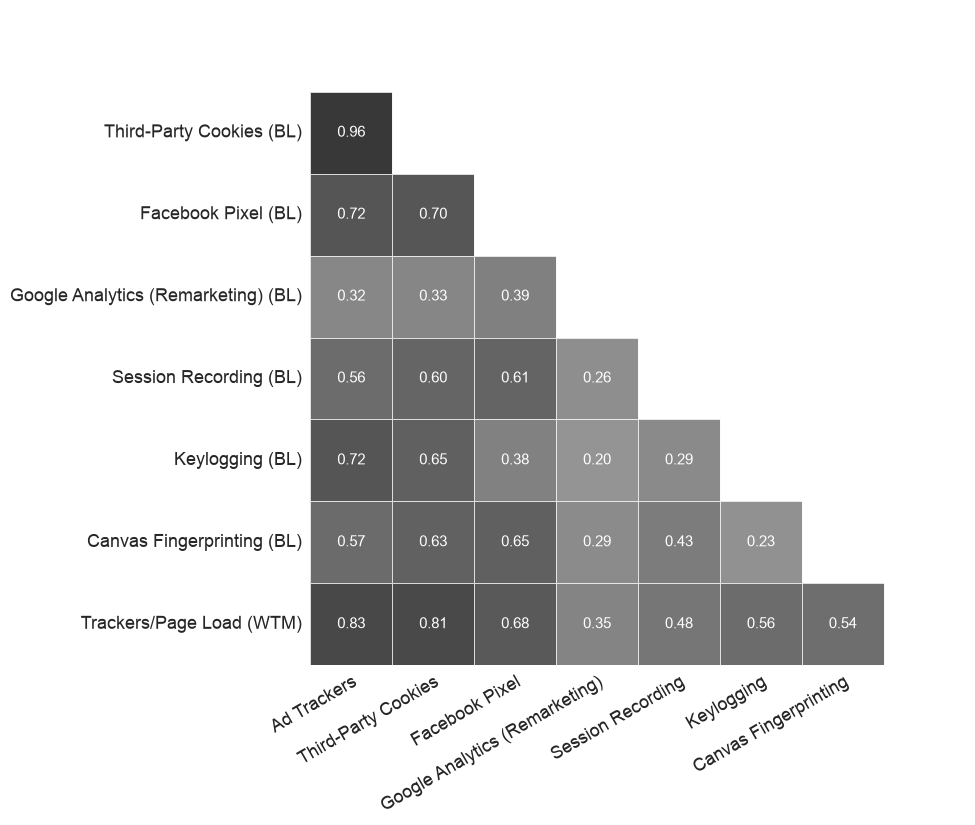

In [30]:
# plot correlations
_scale = 1
_aspect_ratio = (10, 10)
figsize = tuple(k * _scale for k in _aspect_ratio)
fig, ax = plt.subplots(figsize=figsize)

# Heatmap without colorbar for now
sns.heatmap(
    df_corr_,
    # remove upper tri
    mask=np.triu(np.ones_like(df_corr_, dtype=bool)),
    cmap="Greys",
    alpha=0.8,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 11},
    cbar=False,
    ax=ax,
)

# ===============================================================
yticklabels = ax.get_yticklabels()
# remove first redundant label
yticklabels[0] = ""
ax.set_yticklabels(yticklabels)

xticklabels = [label.get_text() for label in ax.get_xticklabels()]
# remove last redundant label
xticklabels[-1] = ""
ax.set_xticklabels(xticklabels, rotation=30, ha="right", rotation_mode="anchor")

ax.tick_params(axis="both", labelsize=13, pad=0)

plt.tight_layout()
# save_mpl_fig("../figures/bl_wtm_correlation_truncated")